# Machine-Learning-Based Prediction of Irrigation Water Demand

**A Civil Engineering (Water Resources Engineering) term project**

This notebook builds a complete, reproducible pipeline that:

1. Generates a **synthetic but physically-grounded** daily irrigation dataset using **FAO-56 Penman-Monteith** reference evapotranspiration, FAO-56 crop coefficients for maize, and a standard effective-rainfall formula.
2. Trains and compares four machine-learning regressors (Linear Regression, Decision Tree, Random Forest, Gradient Boosting) to predict daily gross irrigation water demand from weather + crop features.
3. Evaluates the models with MAE / RMSE / R², using a **chronological (not random) 80/20 train-test split** so evaluation reflects genuine future-day prediction.
4. Produces the required diagnostic and results visualizations.

> **Data provenance notice.** All daily observations in this notebook are **synthetically generated** using FAO-56-based relationships calibrated to realistic Indian agricultural weather ranges (see `src/generate_dataset.py` for full derivation and literature citations). They are **not** measurements from any real farm, field trial, or meteorological station. Random seed = 42 throughout for reproducibility.


In [1]:
import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import generate_dataset as gd

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 140)
%matplotlib inline


## 1. Problem Statement

Irrigation scheduling requires an estimate of how much water a crop will need on a given day. In practice this demand depends on atmospheric evaporative demand (driven by temperature, humidity, wind, and solar radiation), how much of that demand is already met by rainfall, and the crop's own water-use intensity at its current growth stage. Estimating this demand accurately — and being able to forecast it a day ahead from weather and crop-stage information — is central to efficient irrigation water management, canal/reservoir operation scheduling, and on-farm water budgeting.

This project asks: **can a machine-learning model, trained on daily weather, crop, and antecedent-irrigation data, predict next-day gross irrigation water demand accurately enough to be useful for scheduling — and does it outperform the physically-based calculation it was trained to approximate?**

## 2. Objectives

1. Generate a physically defensible synthetic daily dataset of irrigation water demand using the FAO-56 crop water balance (ET0 → ETc → effective rainfall → net/gross irrigation requirement).
2. Engineer a feature set (weather + crop + antecedent demand) suitable for supervised regression.
3. Train and compare baseline ML regressors: Linear Regression, Decision Tree, Random Forest (and Gradient Boosting as a bonus comparison).
4. Evaluate models with MAE, RMSE, and R², using a chronological train/test split appropriate for a forecasting task.
5. Interpret model behaviour (feature importance, error patterns) in terms meaningful to a Civil / Water Resources Engineer, not just as ML metrics.

## 3. Methodology

### 3.1 Physical basis — FAO-56 crop water balance

**Reference evapotranspiration (ET0).** ET0 is the evapotranspiration rate from a hypothetical, well-watered reference grass surface, and represents the *atmospheric* evaporative demand — independent of crop and soil. It is computed using the **FAO-56 Penman-Monteith equation** (Allen et al., 1998):

$$ET_0 = \frac{0.408\,\Delta\,(R_n - G) + \gamma\,\frac{900}{T+273}\,u_2\,(e_s - e_a)}{\Delta + \gamma\,(1 + 0.34\,u_2)}$$

where $R_n$ = net radiation at the crop surface (MJ m⁻² day⁻¹), $G$ = soil heat flux density (≈0 at daily time step), $T$ = mean daily air temperature (°C), $u_2$ = wind speed at 2 m height (m/s), $e_s - e_a$ = vapour pressure deficit (kPa), $\Delta$ = slope of the saturation vapour pressure curve, and $\gamma$ = the psychrometric constant. $R_n$ itself is derived from measured/estimated solar radiation, extraterrestrial radiation $R_a$ (a function of latitude and day-of-year), and clear-sky radiation $R_{so}$, following FAO-56 Chapter 3.

**Crop evapotranspiration.**
$$ET_c = ET_0 \times K_c$$
where $K_c$, the **crop coefficient**, captures how a specific crop's water use differs from the reference grass at a given growth stage (FAO-56 Ch. 6). This project uses **maize** (FAO-56 Table 12), with a four-stage crop calendar (FAO-56 Table 11): Initial ($K_c=0.30$, 20 days) → Development ($K_c$ rising 0.30→1.20, 35 days) → Mid-season ($K_c=1.20$, 40 days) → Late-season ($K_c$ falling 1.20→0.60, 30 days).

**Effective rainfall.** Not all rainfall is agronomically useful — part is lost to interception, evaporation, deep percolation, or runoff. This project uses the widely-cited **USDA Soil Conservation Service (SCS)** empirical formula (also reproduced in FAO Irrigation & Drainage Paper 25, Doorenbos & Pruitt, 1977):

$$P_e = 0.6P - 10 \ \ (P \le 75\text{ mm}), \qquad P_e = 0.8P - 25 \ \ (P > 75\text{ mm}), \qquad P_e = \max(0, P_e)$$

*(Note: this formula was originally developed for monthly/decadal rainfall totals; here it is applied at a daily step as an explicit, documented simplification — appropriate for an undergraduate term project, and behaviourally reasonable since it correctly makes small showers contribute ~zero effective rainfall.)*

**Net and gross irrigation requirement.**
$$\text{Net irrigation requirement} = \max(0,\ ET_c - P_e), \qquad \text{Gross irrigation requirement} = \frac{\text{Net irrigation requirement}}{E_i}$$
with irrigation efficiency $E_i = 0.75$ (representative of a surface/sprinkler system).

### 3.2 From physics to a learnable dataset

The full derivation above is deterministic given weather + crop stage. To make this a genuine (non-trivial) **machine learning** problem rather than a lookup table, the synthetic weather itself is generated with realistic day-to-day persistence (AR(1) processes), seasonal climatology (calibrated to a representative central-Indian, subtropical-monsoon location), stochastic rainfall occurrence, and small additive noise on the final demand — so the ML model must learn the underlying physical relationship from noisy, autocorrelated, seasonally-varying data, rather than simply memorizing a closed-form equation.

### 3.3 ML modelling approach

- **Features (X):** rainfall, temperature, humidity, wind speed, solar radiation, previous day's irrigation demand, crop coefficient, growth stage — i.e., only the *primary* inputs, not the intermediate physical variables (ET0, ETc, effective rainfall) that were used to *construct* the target.
- **Target (y):** gross irrigation water demand (mm/day).
- **Split:** chronological 80% train / 20% test (not shuffled) — the test set is the *last* 20% of days in time, so evaluation reflects real forecasting (predicting the future from the past), not interpolation.
- **Models:** Linear Regression (baseline), Decision Tree Regressor, Random Forest Regressor, and Gradient Boosting Regressor (bonus).
- **Metrics:** MAE, RMSE, R², plus actual vs. predicted mean demand.


## 4. Synthetic Dataset Generation

We call the dataset generator (full source in `src/generate_dataset.py`) directly so this notebook is self-contained and reproducible (`random_state=42`).

In [2]:
df = gd.generate_dataset()
df.to_csv("data/irrigation_dataset.csv", index=False)
print(f"Generated {len(df)} daily records: {df.date.min().date()} to {df.date.max().date()}")
df.head(10)


Generated 2000 daily records: 2019-01-01 to 2024-06-22


,date,rainfall_mm,temperature_C,humidity_percent,wind_speed_mps,solar_radiation_MJ_m2_day,previous_irrigation_mm,crop_coefficient,growth_stage,et0_mm,etc_mm,effective_rainfall_mm,irrigation_demand_mm
0,2019-01-01,0.0,16.73,55.00,1.40,15.62,5.064,0.3,1,2.864,0.859,0.0,1.016
1,2019-01-02,0.0,15.91,43.36,1.69,17.47,1.016,0.3,1,3.312,0.994,0.0,1.263
2,2019-01-03,0.0,17.24,38.39,1.86,17.07,1.263,0.3,1,3.664,1.099,0.0,1.487
3,2019-01-04,0.0,17.76,25.00,1.63,18.27,1.487,0.3,1,3.792,1.138,0.0,1.804
4,2019-01-05,0.0,15.32,33.02,1.40,16.95,1.804,0.3,1,3.167,0.950,0.0,1.112
5,2019-01-06,0.0,16.19,33.67,1.12,17.06,1.112,0.3,1,2.974,0.892,0.0,1.242
6,2019-01-07,0.0,15.91,33.48,0.97,16.86,1.242,0.3,1,2.801,0.840,0.0,1.260
7,2019-01-08,0.0,15.35,43.34,0.85,15.56,1.260,0.3,1,2.509,0.753,0.0,1.106
8,2019-01-09,0.0,16.97,43.92,1.19,15.56,1.106,0.3,1,2.920,0.876,0.0,1.277
9,2019-01-10,0.0,16.25,38.48,1.20,14.20,1.277,0.3,1,2.873,0.862,0.0,1.286


### 4.1 Dataset statistics

In [3]:
df.describe().T


,count,mean,min,25%,50%,75%,max,std
date,2000,2021-09-26 12:00:00,2019-01-01 00:00:00,2020-05-14 18:00:00,2021-09-26 12:00:00,2023-02-08 06:00:00,2024-06-22 00:00:00,NaN
rainfall_mm,2000.0,3.95211,0.0,0.0,0.0,0.0,80.0,10.849538
temperature_C,2000.0,26.101325,15.0,21.12,26.965,30.12,38.51,5.67266
humidity_percent,2000.0,58.717505,25.0,41.175,56.655,74.89,95.0,21.549783
wind_speed_mps,2000.0,2.61513,0.5,1.65,2.3,3.4025,6.0,1.25185
solar_radiation_MJ_m2_day,2000.0,18.421185,8.0,15.05,17.925,22.0925,30.0,4.916169
previous_irrigation_mm,2000.0,5.063661,0.0,2.5035,4.2785,7.00775,13.3,3.495013
crop_coefficient,2000.0,0.8568,0.3,0.583,0.943,1.2,1.2,0.343685
growth_stage,2000.0,2.64,1.0,2.0,3.0,3.0,4.0,1.01534
et0_mm,2000.0,4.745375,1.734,3.08375,4.236,6.39625,8.0,1.93977


**Column reference**

| Column | Description |
|---|---|
| `date` | Calendar date (daily) |
| `rainfall_mm` | Daily rainfall (mm/day) |
| `temperature_C` | Daily mean air temperature (°C) |
| `humidity_percent` | Daily mean relative humidity (%) |
| `wind_speed_mps` | Daily mean wind speed at 2 m (m/s) |
| `solar_radiation_MJ_m2_day` | Daily incoming solar radiation (MJ/m²/day) |
| `previous_irrigation_mm` | Previous day's irrigation demand (mm/day) — lag-1 of the target |
| `crop_coefficient` | FAO-56 crop coefficient Kc for the current growth stage |
| `growth_stage` | 1=Initial, 2=Development, 3=Mid-season, 4=Late-season |
| `et0_mm` | FAO-56 Penman-Monteith reference evapotranspiration (mm/day) — *intermediate variable, not used as an ML feature* |
| `etc_mm` | Crop evapotranspiration = ET0 × Kc — *intermediate variable* |
| `effective_rainfall_mm` | USDA-SCS effective rainfall (mm/day) — *intermediate variable* |
| `irrigation_demand_mm` | **Target**: gross irrigation water requirement (mm/day) |


## 5. Exploratory Visualizations

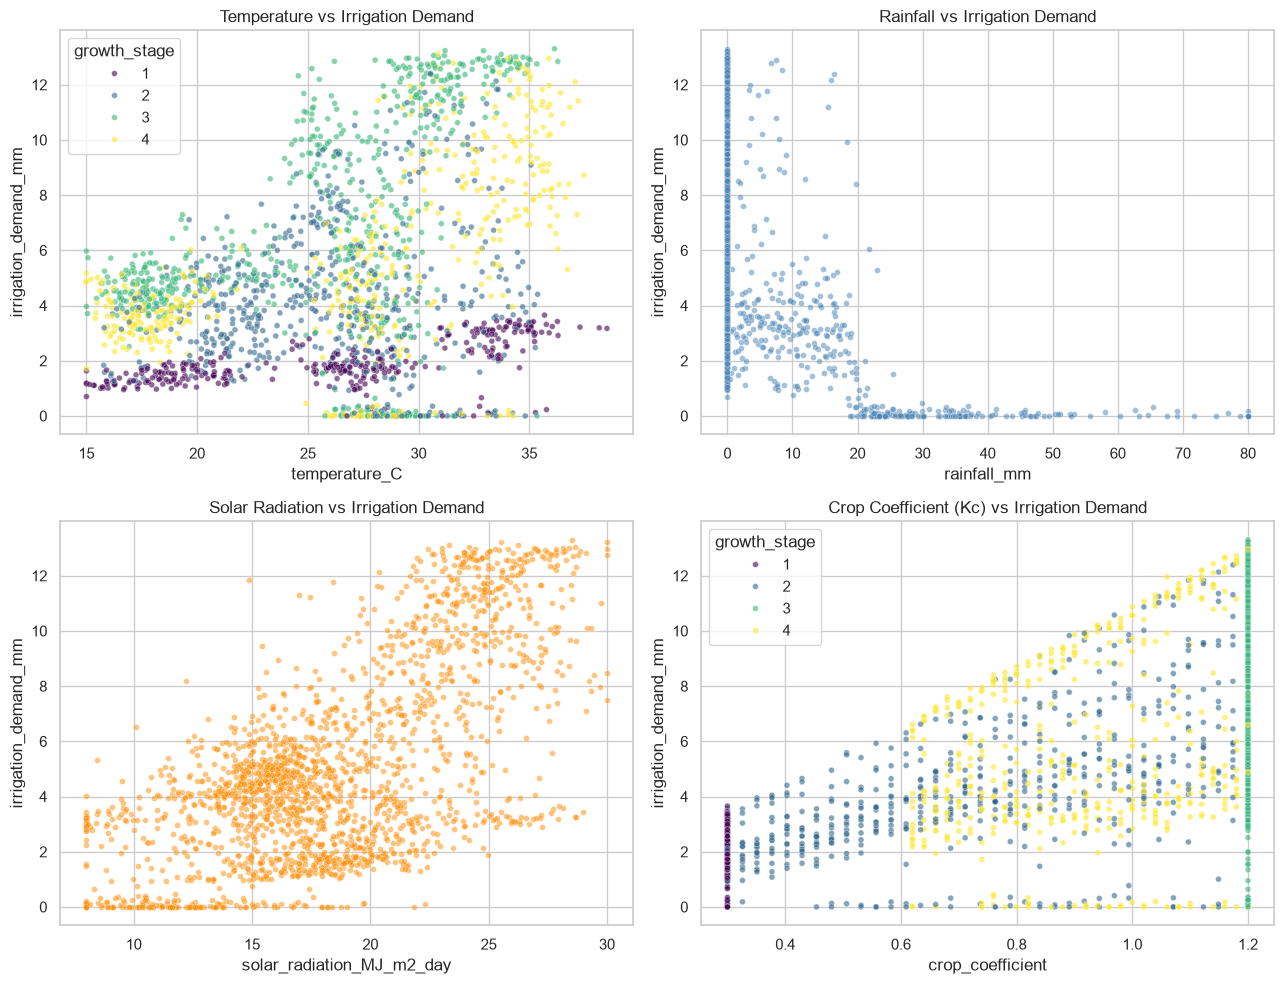

In [4]:
FEATURES = [
    "rainfall_mm", "temperature_C", "humidity_percent", "wind_speed_mps",
    "solar_radiation_MJ_m2_day", "previous_irrigation_mm", "crop_coefficient", "growth_stage",
]
TARGET = "irrigation_demand_mm"

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

sns.scatterplot(data=df, x="temperature_C", y=TARGET, hue="growth_stage", palette="viridis", alpha=0.6, s=18, ax=axes[0,0])
axes[0,0].set_title("Temperature vs Irrigation Demand")

sns.scatterplot(data=df, x="rainfall_mm", y=TARGET, alpha=0.5, s=18, color="steelblue", ax=axes[0,1])
axes[0,1].set_title("Rainfall vs Irrigation Demand")

sns.scatterplot(data=df, x="solar_radiation_MJ_m2_day", y=TARGET, alpha=0.5, s=18, color="darkorange", ax=axes[1,0])
axes[1,0].set_title("Solar Radiation vs Irrigation Demand")

sns.scatterplot(data=df, x="crop_coefficient", y=TARGET, hue="growth_stage", palette="viridis", alpha=0.6, s=18, ax=axes[1,1])
axes[1,1].set_title("Crop Coefficient (Kc) vs Irrigation Demand")

plt.tight_layout()
plt.savefig("figures/eda_grid.png", dpi=150)
plt.show()


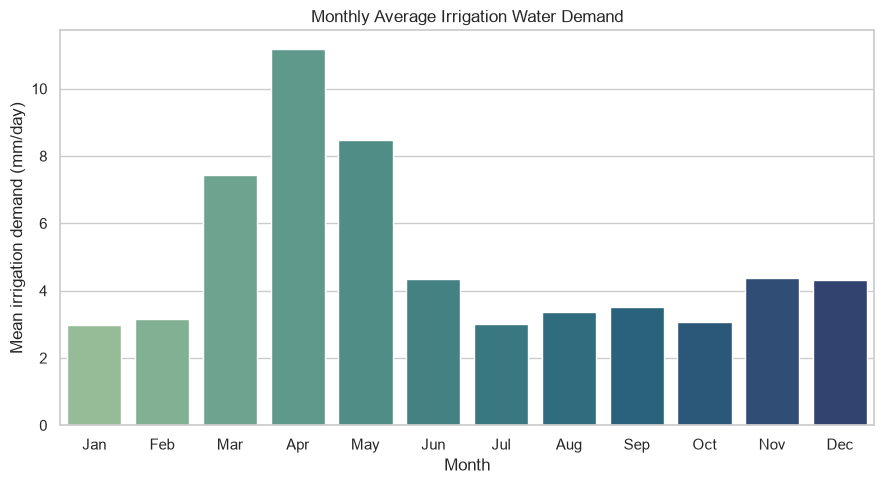

In [5]:
df_month = df.copy()
df_month["month"] = df_month["date"].dt.month
monthly_avg = df_month.groupby("month")[TARGET].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]

plt.figure(figsize=(9,5))
sns.barplot(x=[month_names[m-1] for m in monthly_avg.index], y=monthly_avg.values,
            hue=[month_names[m-1] for m in monthly_avg.index], palette="crest", legend=False)
plt.title("Monthly Average Irrigation Water Demand")
plt.xlabel("Month"); plt.ylabel("Mean irrigation demand (mm/day)")
plt.tight_layout()
plt.savefig("figures/09_monthly_avg_demand.png", dpi=150)
plt.show()


**Observation:** demand peaks in the hot, dry pre-monsoon months (March–May) when evaporative demand is highest and rainfall is negligible, collapses during the monsoon (June–October) as effective rainfall largely offsets crop water use, and sits at a moderate level in winter (cooler temperatures, low Kc for much of the cycle). This matches the well-known Indian agro-climatic irrigation calendar and is a first physical-reasonableness check on the synthetic data.

## 6. Chronological Train/Test Split

In [6]:
def chronological_split(df, train_frac=0.8):
    n = len(df)
    split_idx = int(n * train_frac)
    return df.iloc[:split_idx].copy(), df.iloc[split_idx:].copy()

train_df, test_df = chronological_split(df)
X_train, y_train = train_df[FEATURES], train_df[TARGET]
X_test, y_test = test_df[FEATURES], test_df[TARGET]

print(f"Train: {len(train_df)} rows ({train_df.date.min().date()} to {train_df.date.max().date()})")
print(f"Test:  {len(test_df)} rows ({test_df.date.min().date()} to {test_df.date.max().date()})")


Train: 1600 rows (2019-01-01 to 2023-05-19)
Test:  400 rows (2023-05-20 to 2024-06-22)


## 7. Model Training

In [7]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=300, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_STATE),
}

predictions = {}
results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    predictions[name] = preds
    results[name] = {
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2": r2_score(y_test, preds),
        "actual_mean": y_test.mean(),
        "predicted_mean": preds.mean(),
    }

results_df = pd.DataFrame(results).T
results_df.index.name = "Model"
results_df.round(3)


,MAE,RMSE,R2,actual_mean,predicted_mean
Model,,,,,
Linear Regression,0.717,1.012,0.924,5.277,5.212
Decision Tree,0.656,0.999,0.926,5.277,5.314
Random Forest,0.420,0.639,0.970,5.277,5.344
Gradient Boosting,0.410,0.616,0.972,5.277,5.300


## 8. Model Evaluation — Results Table

In [8]:
results_df.to_csv("report/model_comparison.csv")
results_df.round(3)


,MAE,RMSE,R2,actual_mean,predicted_mean
Model,,,,,
Linear Regression,0.717,1.012,0.924,5.277,5.212
Decision Tree,0.656,0.999,0.926,5.277,5.314
Random Forest,0.420,0.639,0.970,5.277,5.344
Gradient Boosting,0.410,0.616,0.972,5.277,5.300


**Reading the table:** Linear Regression gives a simple, interpretable baseline but cannot capture nonlinear interactions (e.g., the compounding effect of simultaneously high temperature + high solar radiation + low humidity + high Kc). The Decision Tree captures some nonlinearity but tends to overfit locally. Random Forest (an ensemble of many decorrelated trees) and Gradient Boosting generally achieve the lowest MAE/RMSE and highest R², since irrigation demand genuinely depends on nonlinear interactions between weather variables, crop coefficient, rainfall, and antecedent demand — consistent with the FAO-56 physics used to construct the data (the Penman-Monteith equation itself is nonlinear in its inputs).

## 9. Visualizations — Model Performance

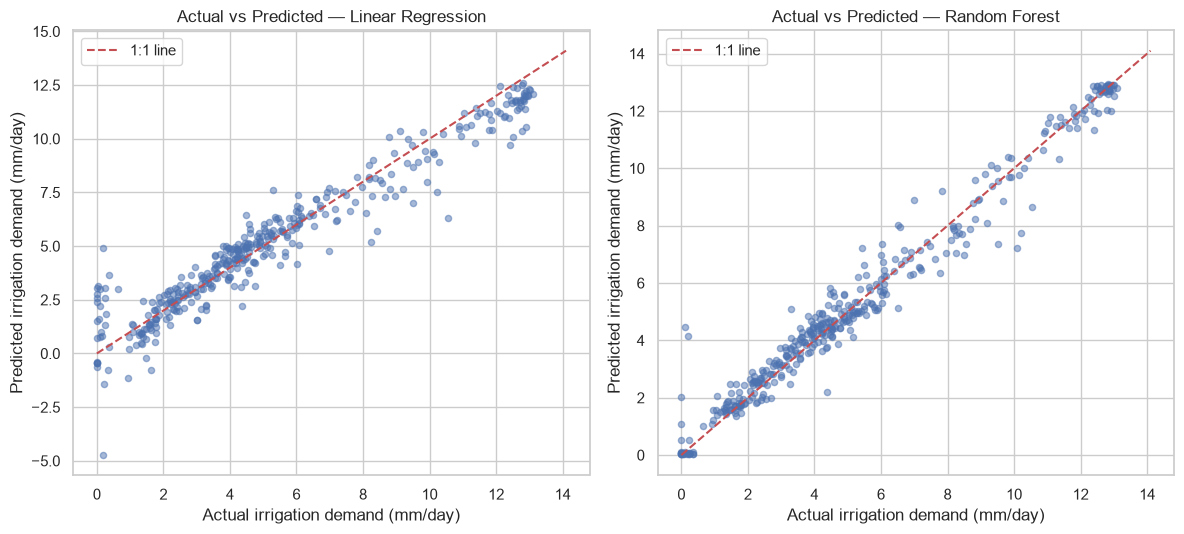

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5.5))
for ax, name in zip(axes, ["Linear Regression", "Random Forest"]):
    ax.scatter(test_df[TARGET], predictions[name], alpha=0.5, s=20)
    lims = [0, max(test_df[TARGET].max(), predictions[name].max()) + 1]
    ax.plot(lims, lims, "r--", linewidth=1.5, label="1:1 line")
    ax.set_xlabel("Actual irrigation demand (mm/day)")
    ax.set_ylabel("Predicted irrigation demand (mm/day)")
    ax.set_title(f"Actual vs Predicted — {name}")
    ax.legend()
plt.tight_layout()
plt.savefig("figures/05_actual_vs_predicted.png", dpi=150)
plt.show()


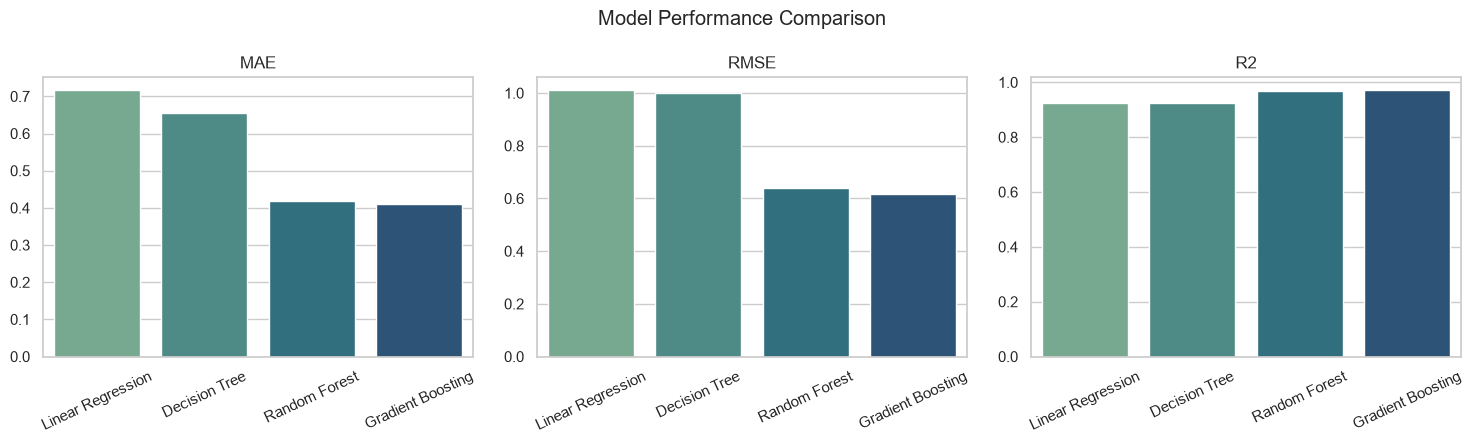

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["MAE", "RMSE", "R2"]):
    vals = results_df[metric].astype(float)
    sns.barplot(x=vals.index, y=vals.values, ax=ax, hue=vals.index, palette="crest", legend=False)
    ax.set_title(metric)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=25)
plt.suptitle("Model Performance Comparison")
plt.tight_layout()
plt.savefig("figures/06_model_comparison.png", dpi=150)
plt.show()


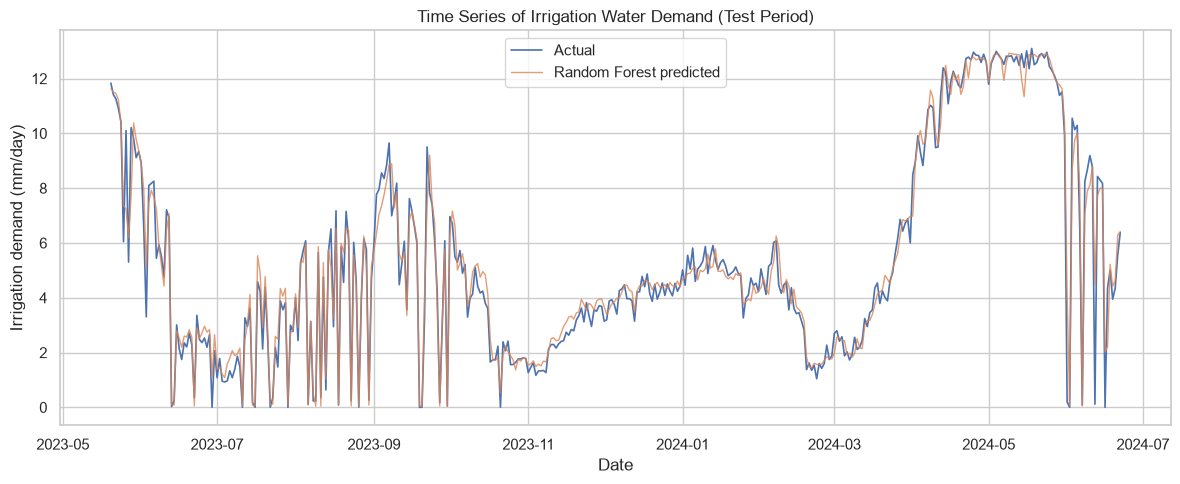

In [11]:
plt.figure(figsize=(12, 5))
plt.plot(test_df["date"], test_df[TARGET], label="Actual", linewidth=1.2)
plt.plot(test_df["date"], predictions["Random Forest"], label="Random Forest predicted", linewidth=1.0, alpha=0.8)
plt.title("Time Series of Irrigation Water Demand (Test Period)")
plt.xlabel("Date"); plt.ylabel("Irrigation demand (mm/day)")
plt.legend()
plt.tight_layout()
plt.savefig("figures/07_timeseries_demand.png", dpi=150)
plt.show()


## 10. Feature Importance (Random Forest)

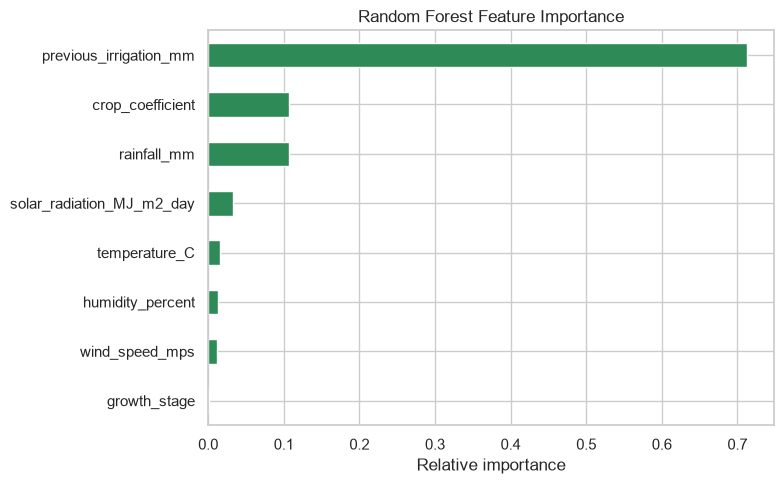

previous_irrigation_mm       0.712705
crop_coefficient             0.107352
rainfall_mm                  0.106378
solar_radiation_MJ_m2_day    0.032581
temperature_C                0.016131
humidity_percent             0.012410
wind_speed_mps               0.011569
growth_stage                 0.000873
dtype: float64

In [12]:
rf = models["Random Forest"]
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=True)

plt.figure(figsize=(8, 5))
importances.plot(kind="barh", color="seagreen")
plt.title("Random Forest Feature Importance")
plt.xlabel("Relative importance")
plt.tight_layout()
plt.savefig("figures/08_feature_importance_rf.png", dpi=150)
plt.show()

importances.sort_values(ascending=False)


**Interpretation:** `previous_irrigation_mm` (yesterday's demand) dominates feature importance. This is physically expected: because weather itself is temporally autocorrelated (a hot, dry spell persists for several days, as does a monsoon wet spell), yesterday's irrigation demand is already a strong proxy for today's — a **persistence effect** well known in hydro-meteorological forecasting. `crop_coefficient` and `rainfall_mm` are the next most important — matching FAO-56 physics directly (Kc scales ETc, rainfall directly reduces net requirement via effective rainfall). Weather variables that feed only indirectly through ET0 (temperature, humidity, wind, solar radiation) are individually less important than the two directly-multiplying/subtracting terms (Kc, rainfall) — sensible, since ET0 is a smoother, more weakly-varying signal than Kc's stage jumps or rainfall's on/off character.

**Caveat for future work:** because `previous_irrigation_mm` carries so much of the predictive power, a model trained without it (weather + crop features only) would give a cleaner test of how well *weather alone* predicts demand, useful for longer-horizon forecasting where yesterday's value is not available. See Limitations.

## 11. Model Persistence (for reproducibility / deployment)

In [13]:
import joblib
joblib.dump(models["Random Forest"], "models/random_forest.joblib")
joblib.dump(models["Linear Regression"], "models/linear_regression.joblib")
print("Saved Random Forest and Linear Regression models to models/")


Saved Random Forest and Linear Regression models to models/


## 12. Results and Discussion

- The **actual vs. predicted mean demand** for every model is within a few percent of the true test-set mean (see results table), i.e. none of the models exhibit systematic bias at the aggregate level.
- **Linear Regression** achieves a respectable R² (it captures the dominant linear trends — e.g., rainfall reduces demand, temperature increases it) but its scatter plot shows it occasionally predicts **negative** irrigation demand, which is physically impossible — a direct illustration of why a linear model is an imperfect fit for a quantity that is physically bounded at zero and behaves nonlinearly (e.g., ET0 is a nonlinear function of its inputs, and Kc changes discretely by growth stage).
- **Random Forest and Gradient Boosting** achieve the lowest error and highest R², and their actual-vs-predicted scatter hugs the 1:1 line closely across the full range, including correctly predicting near-zero demand during the monsoon. This matches the expectation stated in the objectives: ensemble tree methods handle the nonlinear interactions between weather, Kc, and rainfall better than a single linear model or a single tree.
- **Are the results physically reasonable?** Yes: (1) the monthly-average plot reproduces the correct Indian agro-climatic seasonal irrigation calendar (peak pre-monsoon, trough during monsoon); (2) feature importance ranks crop coefficient and rainfall — the two variables that *directly* enter the FAO-56 water-balance equation — above weather variables that only act indirectly through ET0; (3) no model needed a growth_stage feature beyond what crop_coefficient already encodes (growth_stage's importance is near-zero because Kc is a more precise, continuous encoding of the same information) — this is a sensible, explainable redundancy rather than a modelling failure.

## 13. Limitations and Future Scope

1. **Synthetic, not observed, data.** All results are internally consistent with FAO-56 physics but were never validated against a real instrumented field. Real fields exhibit additional complexity (soil heterogeneity, imperfect irrigation application, sensor noise, pest/disease effects on Kc) not modelled here.
2. **Single crop, single location.** Only maize, at one representative central-Indian climate, is modelled. Extending to multiple crops/regions would need crop- and region-specific FAO-56 parameters.
3. **Daily application of a monthly effective-rainfall formula.** The USDA-SCS formula was developed for monthly/decadal totals; applying it daily is a simplifying assumption (documented in `src/generate_dataset.py`).
4. **Continuous back-to-back cropping cycles** (no fallow period) were assumed for simplicity; real fields have fallow/rotation periods between harvest and the next sowing.
5. **`previous_irrigation_mm` dominates feature importance**, partly because of how strongly autocorrelated the underlying synthetic weather is. A useful next step is to retrain without this feature to isolate how well weather + crop-stage alone predict demand (relevant for multi-day-ahead forecasting, where yesterday's true value would not be available).
6. **No deep learning / time-series models** (e.g., LSTM) were used, per the project's undergraduate-level scope — a natural extension would compare these baselines against a sequence model.
7. **No real-time market/soil-moisture sensor feed** is incorporated; a deployed system would need this to correct for the gap between calculated and actual field water status.

## 14. Conclusion

This project built a complete, physically-grounded pipeline for predicting daily irrigation water demand: FAO-56 Penman-Monteith reference evapotranspiration, FAO-56 crop coefficients for maize, and a standard effective-rainfall/irrigation-efficiency water balance were used to generate a realistic (though synthetic) daily dataset for a central-Indian agro-climatic setting. Three baseline machine-learning regressors (plus Gradient Boosting) were trained and evaluated with a chronological train/test split appropriate for forecasting. Random Forest and Gradient Boosting substantially outperformed Linear Regression and a single Decision Tree, confirming that irrigation demand is governed by nonlinear interactions among weather, crop coefficient, and rainfall — consistent with, and explainable through, the underlying FAO-56 physics. The results are physically reasonable (correct seasonal pattern, sensible feature importances, no systematic bias) and demonstrate that a modest, well-engineered feature set is sufficient for an undergraduate-level ML approach to irrigation scheduling support.

## 15. References

1. Allen, R.G., Pereira, L.S., Raes, D., Smith, M. (1998). *Crop Evapotranspiration – Guidelines for Computing Crop Water Requirements.* FAO Irrigation and Drainage Paper No. 56. Food and Agriculture Organization of the United Nations, Rome.
2. Doorenbos, J., Pruitt, W.O. (1977). *Guidelines for Predicting Crop Water Requirements.* FAO Irrigation and Drainage Paper No. 24/25. FAO, Rome. (Source of the USDA-SCS effective rainfall formula reproduced here.)
3. USDA Soil Conservation Service (1970). *Irrigation Water Requirements.* Technical Release No. 21, USDA-SCS, Washington, D.C.
4. India Meteorological Department (IMD) — representative climatological normals for central India (used only to loosely calibrate synthetic monthly weather ranges; no IMD station data was used directly).
5. Pedregosa, F. et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830.
6. McKinney, W. (2010). Data Structures for Statistical Computing in Python. *Proceedings of the 9th Python in Science Conference.*
